# 目标检测 Notebook

本 Notebook 实现基于微调模型的图像目标检测功能。

## 功能特点
1. **模型加载** - 支持加载微调后的模型权重
2. **图像输入** - 支持本地路径和网络URL两种方式
3. **目标检测** - 识别用户指定的目标类别
4. **可视化** - 在原图上绘制检测框和标签

---

## 0. 环境配置与依赖安装

In [1]:
import json
import os
import sys
import traceback
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

warnings.filterwarnings("ignore")

try:
    import torch

    print(f"PyTorch 版本: {torch.__version__}")
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"GPU: {gpu_name}")
        print(f"VRAM: {gpu_memory:.1f} GB")
    else:
        print("警告: 未检测到 GPU，推理将较慢")
except ImportError:
    print("请先安装 PyTorch: pip install torch")
    sys.exit(1)

PyTorch 版本: 2.10.0+cu128
GPU: NVIDIA RTX 5880 Ada Generation
VRAM: 47.4 GB


In [2]:
try:
    from io import BytesIO

    import matplotlib.pyplot as plt
    import numpy as np
    import requests
    from PIL import Image, ImageDraw, ImageFont

    print("图像处理库导入成功")
except ImportError as e:
    print(f"缺少依赖: {e}")
    print("请安装: pip install pillow matplotlib requests")
    sys.exit(1)

图像处理库导入成功


## 1. 配置参数

修改以下配置单元格中的参数即可适配不同环境。所有路径基于 `PROJECT_ROOT` 自动推导。

**跨Notebook参数关联:**
- `BASE_MODEL_PATH`: 与 **02-微调** Notebook 中的基础模型路径保持一致
- `LORA_ADAPTER_PATH`: 由 **02-微调** Notebook 生成的 LoRA 适配器路径

In [3]:
# ============================================================
# 项目路径与全局配置
# ============================================================
# 【重要】修改以下参数即可适配不同环境，无需改动其他单元格

from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

# 定位项目根目录: 优先搜索 cwd, 其次搜索 VS Code notebook 文件路径
_nb_file = globals().get('__vsc_ipynb_file__', '')
_search_starts = [NOTEBOOK_DIR] + ([Path(_nb_file).parent] if _nb_file else [])
PROJECT_ROOT = None
for _s in _search_starts:
    for _p in [_s] + list(_s.parents):
        if (_p / 'pyproject.toml').exists():
            PROJECT_ROOT = _p
            break
    if PROJECT_ROOT:
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = NOTEBOOK_DIR.parent  # fallback: assume cwd is <root>/notebooks/

# ---------- 模型路径配置 ----------
# 基础模型路径 (与02-微调Notebook中的BASE_MODEL_PATH一致)
# BASE_MODEL_PATH = "unsloth/gemma-4-E4B-it-bnb-4bit"  # HuggingFace在线模型 (推荐)
BASE_MODEL_PATH = "/raid5/sh/model/unsloth/gemma-4-E4B-it-unsloth-bnb-4bit"
# BASE_MODEL_PATH = str(PROJECT_ROOT / "models" / "base" / "gemma-4-E4B-it-unsloth-bnb-4bit")  # 本地路径

# LoRA适配器路径 (由02-微调Notebook生成)
LORA_ADAPTER_PATH = str(PROJECT_ROOT / "models" / "finetuned" / "gemma4_e4b_lora")

# ---------- 模型加载参数 ----------
MAX_SEQ_LENGTH = 2048  # 最大序列长度
LOAD_IN_4BIT = True  # 是否使用4-bit量化
DEVICE_MAP = "cuda:0"  # 设备映射 (可选: "cuda:0", "balanced", "auto")

# ---------- 推理参数 ----------
INFERENCE_MAX_NEW_TOKENS = 512  # 推理最大生成token数
INFERENCE_TEMPERATURE = 0.7  # 推理温度 (越高越随机, 取值范围: 0-2)
INFERENCE_TOP_P = 0.9  # 推理top_p (nucleus sampling, 取值范围: 0-1)

# ---------- 测试数据配置 ----------
TEST_IMAGE_URL = "https://fsimage.guihuao.com/images/28b37a22-2e2e-4adc-8e94-eedc986d26a9/5147493742738931713.jpeg?imageMogr2/crop/!1353x1353a1311a823"
TEST_QUERY = "检测图中的水面绿藻, 使用green algae作为标签"
TEST_OUTPUT_PATH = "test_detection_result.jpg"

print(f"项目根目录: {PROJECT_ROOT}")
print(f"基础模型: {BASE_MODEL_PATH}")
print(f"LoRA适配器: {LORA_ADAPTER_PATH}")

项目根目录: /raid5/sh/code/vlm-detect
基础模型: /raid5/sh/model/unsloth/gemma-4-E4B-it-unsloth-bnb-4bit
LoRA适配器: /raid5/sh/code/vlm-detect/models/finetuned/gemma4_e4b_lora


## 2. 模型配置

所有模型路径参数已在上方 **0. 配置参数** 单元格中集中定义，`MODEL_CONFIG` 自动读取这些值。

In [4]:
# ============================================================
# 模型路径配置 — 所有参数已在上方配置单元格中集中定义
# ============================================================

MODEL_CONFIG = {
    "base_model_path": BASE_MODEL_PATH,
    "lora_adapter_path": LORA_ADAPTER_PATH,
    "max_seq_length": MAX_SEQ_LENGTH,
    "load_in_4bit": LOAD_IN_4BIT,
    "device_map": DEVICE_MAP,
}

print("模型配置:")
for key, value in MODEL_CONFIG.items():
    print(f"  {key}: {value}")

模型配置:
  base_model_path: /raid5/sh/model/unsloth/gemma-4-E4B-it-unsloth-bnb-4bit
  lora_adapter_path: /raid5/sh/code/vlm-detect/models/finetuned/gemma4_e4b_lora
  max_seq_length: 2048
  load_in_4bit: True
  device_map: cuda:0


## 3. 模型加载模块

In [5]:
class ModelLoader:
    """
    视觉模型加载器，支持加载 Gemma 4 多模态模型和 LoRA adapter
    重要: Gemma 4 视觉模型需要使用 FastVisionModel 和 processor
    """

    def __init__(self, config: Dict[str, Any]):
        self.config = config
        self.model = None
        self.processor = None  # 注意: 使用 processor 替代 tokenizer
        self._is_loaded = False

    def _patch_peft_for_gemma4(self) -> bool:
        """
        修复PEFT对Gemma4ClippableLinear的支持
        参考: https://github.com/huggingface/peft/issues/3130

        使用类名字符串匹配代替isinstance, 避免Unsloth monkey-patch导致的类身份不匹配
        注意: _create_new_module 是静态方法, 必须用 staticmethod() 替代
        """
        try:
            from peft.tuners.lora import model as lora_model

            _original = lora_model.LoraModel._create_new_module

            def _patch(lora_config, adapter_name, target, **kwargs):
                # 使用类名字符串匹配 + hasattr检查, 避免isinstance因Unsloth patch导致的类身份不匹配
                if target.__class__.__name__ == "Gemma4ClippableLinear" and hasattr(target, "linear"):
                    return _original(lora_config, adapter_name, target.linear, **kwargs)
                return _original(lora_config, adapter_name, target, **kwargs)

            lora_model.LoraModel._create_new_module = staticmethod(_patch)
            print("PEFT已patch，支持Gemma4ClippableLinear")
            return True
        except Exception as e:
            print(f"Patch失败: {e}")
            print("将使用exclude_modules方式加载")
            return False

    def load_model(self) -> bool:
        """加载视觉模型和 processor"""
        try:
            print("正在加载视觉模型...")
            os.environ["UNSLOTH_DISABLE_STATISTICS"] = "1"

            from unsloth import FastVisionModel

            base_path = self.config["base_model_path"]
            lora_path = self.config["lora_adapter_path"]

            if not os.path.exists(base_path):
                raise FileNotFoundError(f"基础模型路径不存在: {base_path}")

            self.model, self.processor = FastVisionModel.from_pretrained(
                model_name=base_path,
                max_seq_length=self.config["max_seq_length"],
                load_in_4bit=self.config["load_in_4bit"],
                device_map=self.config["device_map"],
                disable_log_stats=True,
            )
            print("视觉模型加载成功")

            if os.path.exists(lora_path):
                print(f"正在加载 LoRA adapter: {lora_path}")
                self._patch_peft_for_gemma4()

                from peft import PeftModel

                self.model = PeftModel.from_pretrained(
                    self.model, lora_path, is_trainable=False
                )
                print("LoRA adapter 加载成功")
            else:
                print(f"LoRA adapter 路径不存在: {lora_path}")
                print("将使用基础模型进行推理")

            self._is_loaded = True
            return True

        except Exception as e:
            print(f"模型加载失败: {e}")
            traceback.print_exc()
            return False

    def is_loaded(self) -> bool:
        """检查模型是否已加载"""
        return self._is_loaded

    def get_model_info(self) -> Dict[str, Any]:
        """获取模型信息"""
        if not self._is_loaded:
            return {"status": "未加载"}

        total_params = sum(p.numel() for p in self.model.parameters())
        return {
            "status": "已加载",
            "total_params": total_params,
            "params_billion": total_params / 1e9,
        }

In [6]:
model_loader = ModelLoader(MODEL_CONFIG)
load_success = model_loader.load_model()

if load_success:
    print("\n模型信息:")
    info = model_loader.get_model_info()
    for key, value in info.items():
        print(f"  {key}: {value}")
else:
    print("\n模型加载失败，请检查配置和路径")

正在加载视觉模型...
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.6: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX 5880 Ada Generation. Num GPUs = 8. Max memory: 47.372 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

视觉模型加载成功
正在加载 LoRA adapter: /raid5/sh/code/vlm-detect/models/finetuned/gemma4_e4b_lora
PEFT已patch，支持Gemma4ClippableLinear
LoRA adapter 加载成功

模型信息:
  status: 已加载
  total_params: 6301854240
  params_billion: 6.30185424


## 4. 图像加载模块

In [7]:
class ImageLoader:
    """
    图像加载器，支持本地路径和网络 URL
    """

    SUPPORTED_FORMATS = [".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"]

    def __init__(self):
        self.image = None
        self.image_path = None
        self._width = 0
        self._height = 0

    def load_from_local(self, path: str) -> bool:
        """从本地路径加载图像"""
        try:
            path_obj = Path(path)

            if not path_obj.exists():
                raise FileNotFoundError(f"文件不存在: {path}")

            if path_obj.suffix.lower() not in self.SUPPORTED_FORMATS:
                raise ValueError(f"不支持的图像格式: {path_obj.suffix}")

            self.image = Image.open(path).convert("RGB")
            self.image_path = path
            self._width, self._height = self.image.size
            print(f"图像加载成功: {path}")
            print(f"尺寸: {self._width} x {self._height}")
            return True

        except Exception as e:
            print(f"本地图像加载失败: {e}")
            return False

    def load_from_url(self, url: str, timeout: int = 30) -> bool:
        """从 URL 加载图像"""
        try:
            print(f"正在从 URL 下载图像: {url}")

            response = requests.get(url, timeout=timeout, stream=True)
            response.raise_for_status()

            content_type = response.headers.get("content-type", "")
            if "image" not in content_type:
                raise ValueError(f"URL 不是图像类型: {content_type}")

            image_data = BytesIO(response.content)
            self.image = Image.open(image_data).convert("RGB")
            self.image_path = url
            self._width, self._height = self.image.size
            print("图像下载成功")
            print(f"尺寸: {self._width} x {self._height}")
            return True

        except requests.exceptions.Timeout:
            print(f"请求超时 ({timeout}秒)")
            return False
        except requests.exceptions.RequestException as e:
            print(f"网络请求失败: {e}")
            return False
        except Exception as e:
            print(f"URL 图像加载失败: {e}")
            return False

    def load(self, source: str) -> bool:
        """自动判断来源并加载图像"""
        if source.startswith("http://") or source.startswith("https://"):
            return self.load_from_url(source)
        else:
            return self.load_from_local(source)

    def get_image(self) -> Optional[Image.Image]:
        """获取加载的图像"""
        return self.image

    def get_size(self) -> Tuple[int, int]:
        """获取图像尺寸"""
        return (self._width, self._height)

    def display(self, title: str = "图像") -> None:
        """显示图像"""
        if self.image is None:
            print("未加载图像")
            return

        plt.figure(figsize=(10, 8))
        plt.imshow(self.image)
        plt.title(title)
        plt.axis("off")
        plt.tight_layout()
        plt.show()

In [8]:
image_loader = ImageLoader()
print("图像加载器已初始化")
print(f"支持的格式: {ImageLoader.SUPPORTED_FORMATS}")

图像加载器已初始化
支持的格式: ['.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp']


## 5. 目标检测模块

In [9]:
class ObjectDetector:
    """
    目标检测器，使用加载的模型进行推理
    """

    def __init__(self, model_loader: ModelLoader):
        self.model_loader = model_loader
        self._results_cache = {}

    def _build_prompt(self, query: str) -> str:
        """构建检测提示词，约束模型返回格式"""
        prompt = f"""请仔细分析这张图片，{query}。

如果检测到目标，请严格按照以下JSON格式返回检测结果（不要添加其他文字说明）:
[
  {{"box_2d": [y1, x1, y2, x2], "label": "目标类别", "confidence": 置信度}}
]

坐标说明:
- box_2d: 边界框坐标 [y1, x1, y2, x2]，基于1000x1000坐标系
- y1, y2: 垂直方向坐标 (0-1000)，y1 < y2
- x1, x2: 水平方向坐标 (0-1000)，x1 < x2
- confidence: 置信度分数 (0.0-1.0)

如果未检测到目标，请返回空数组: []"""
        return prompt

    def detect(
        self, image: Image.Image, query: str, max_new_tokens: int = 512
    ) -> Dict[str, Any]:
        """对图像进行目标检测 - 使用 Gemma 4 正确的视觉输入方式"""
        if not self.model_loader.is_loaded():
            return {"error": "模型未加载", "success": False}

        try:
            model = self.model_loader.model
            processor = self.model_loader.processor

            prompt = self._build_prompt(query)

            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": image},
                        {"type": "text", "text": prompt},
                    ],
                }
            ]

            inputs = processor.apply_chat_template(
                messages,
                tokenize=True,
                add_generation_prompt=True,
                return_tensors="pt",
                return_dict=True,
            ).to(model.device)

            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    use_cache=True,
                    temperature=0.7,
                    top_p=0.9,
                    do_sample=True,
                )

            response = processor.batch_decode(outputs, skip_special_tokens=True)[0]

            width, height = image.size
            detections = self._parse_response(response, query, width, height)

            return {
                "success": True,
                "raw_response": response,
                "detections": detections,
                "query": query,
            }

        except Exception as e:
            return {"error": str(e), "success": False}

    def _parse_response(
        self, response: str, query: str, width: int, height: int
    ) -> List[Dict[str, Any]]:
        """解析模型响应，提取检测结果
        支持两种坐标格式:
        1. Gemma 4 标准: box_2d 为 [y1, x1, y2, x2]，坐标基于 1000x1000
        2. 归一化坐标: [y1, x1, y2, x2]，坐标范围 0-1 (Normalized)
        参考: https://huggingface.co/blog/gemma4
        """
        import json
        import re

        detections = []
        scale_1000_x = width / 1000.0
        scale_1000_y = height / 1000.0

        def _is_normalized(coords: list) -> bool:
            """判断坐标是否为归一化格式(0-1范围)"""
            return all(0 <= v <= 1 for v in coords)

        def _convert_coords(coords: list, w: int, h: int) -> tuple:
            """将坐标转换为像素坐标，自动判断格式"""
            if _is_normalized(coords):
                x1 = int(coords[1] * w)
                y1 = int(coords[0] * h)
                x2 = int(coords[3] * w)
                y2 = int(coords[2] * h)
            else:
                x1 = int(coords[1] * scale_1000_x)
                y1 = int(coords[0] * scale_1000_y)
                x2 = int(coords[3] * scale_1000_x)
                y2 = int(coords[2] * scale_1000_y)
            return (x1, y1, x2, y2)

        def _extract_json_array(text: str) -> Optional[str]:
            """从文本中提取 JSON 数组，使用括号匹配"""
            json_block = re.search(r"```json\s*([\s\S]*?)\s*```", text)
            if json_block:
                return json_block.group(1).strip()

            start_idx = text.find("[")
            if start_idx == -1:
                return None

            bracket_count = 0
            for i, char in enumerate(text[start_idx:], start_idx):
                if char == "[":
                    bracket_count += 1
                elif char == "]":
                    bracket_count -= 1
                    if bracket_count == 0:
                        return text[start_idx : i + 1]
            return None

        json_str = _extract_json_array(response)
        if json_str:
            try:
                json_data = json.loads(json_str)
                for item in json_data:
                    if "box_2d" in item and len(item["box_2d"]) == 4:
                        coords = item["box_2d"]
                        label = item.get("label", "目标")
                        x1, y1, x2, y2 = _convert_coords(coords, width, height)
                        if 0 <= x1 < width and 0 <= y1 < height:
                            detections.append(
                                {
                                    "bbox": [x1, y1, x2, y2],
                                    "label": label,
                                    "confidence": 0.85,
                                }
                            )
                if detections:
                    return detections
            except (json.JSONDecodeError, KeyError, TypeError):
                pass

        obj_pattern = r'\{[^{}]*"box_2d"[^{}]*\}'
        obj_matches = re.findall(obj_pattern, response, re.DOTALL)

        for obj_str in obj_matches:
            try:
                obj = json.loads(obj_str)
                if "box_2d" in obj and len(obj["box_2d"]) == 4:
                    coords = obj["box_2d"]
                    label = obj.get("label", "目标")
                    x1, y1, x2, y2 = _convert_coords(coords, width, height)
                    if 0 <= x1 < width and 0 <= y1 < height:
                        detections.append(
                            {
                                "bbox": [x1, y1, x2, y2],
                                "label": label,
                                "confidence": 0.85,
                            }
                        )
            except (json.JSONDecodeError, KeyError, TypeError):
                pass

        if detections:
            return detections

        bbox_pattern_int = (
            r'box_2d["\']?\s*[:=]\s*\[\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*\]'
        )
        bbox_matches_int = re.findall(bbox_pattern_int, response)

        bbox_pattern_float = r'box_2d["\']?\s*[:=]\s*\[\s*(\d+\.?\d*)\s*,\s*(\d+\.?\d*)\s*,\s*(\d+\.?\d*)\s*,\s*(\d+\.?\d*)\s*\]'
        bbox_matches_float = re.findall(bbox_pattern_float, response)

        label_match = re.search(r'"label"["\']?\s*:\s*"([^"]+)"', response)
        default_label = label_match.group(1) if label_match else "目标"

        for match in bbox_matches_float:
            try:
                coords = [float(v) for v in match]
                x1, y1, x2, y2 = _convert_coords(coords, width, height)
                if 0 <= x1 < width and 0 <= y1 < height:
                    detections.append(
                        {
                            "bbox": [x1, y1, x2, y2],
                            "label": default_label,
                            "confidence": 0.85,
                        }
                    )
            except ValueError:
                continue

        for match in bbox_matches_int:
            try:
                coords = [int(v) for v in match]
                x1, y1, x2, y2 = _convert_coords(coords, width, height)
                if 0 <= x1 < width and 0 <= y1 < height:
                    detections.append(
                        {
                            "bbox": [x1, y1, x2, y2],
                            "label": default_label,
                            "confidence": 0.85,
                        }
                    )
            except ValueError:
                continue

        normalized_pattern = r"\[\s*(\d+\.?\d*)\s*,\s*(\d+\.?\d*)\s*,\s*(\d+\.?\d*)\s*,\s*(\d+\.?\d*)\s*\]\s*.*?(?:置信度|confidence)[:\s]*(\d+\.?\d*)"
        norm_matches = re.findall(normalized_pattern, response)

        for match in norm_matches:
            try:
                coords = [float(v) for v in match[:4]]
                if _is_normalized(coords):
                    confidence = float(match[4]) if len(match) > 4 else 0.85
                    x1, y1, x2, y2 = _convert_coords(coords, width, height)
                    if 0 <= x1 < width and 0 <= y1 < height:
                        detections.append(
                            {
                                "bbox": [x1, y1, x2, y2],
                                "label": default_label,
                                "confidence": min(confidence, 1.0),
                            }
                        )
            except ValueError:
                continue

        bbox_keyword_pattern = r"(?:边界框坐标|Bounding\s*Box\s*Coordinates?|bbox)[:\s]*[`\'\"]?\s*\[\s*(\d+\.?\d*)\s*,\s*(\d+\.?\d*)\s*,\s*(\d+\.?\d*)\s*,\s*(\d+\.?\d*)\s*\][`\'\"]?"
        bbox_keyword_matches = re.findall(bbox_keyword_pattern, response, re.IGNORECASE)

        conf_pattern = r"(?:置信度|Confidence\s*Score)[:\s*]*[\*]*\s*(\d+\.?\d*)"
        conf_match = re.search(conf_pattern, response, re.IGNORECASE)
        extracted_confidence = float(conf_match.group(1)) if conf_match else 0.85

        for match in bbox_keyword_matches:
            try:
                coords = [float(v) for v in match]
                x1, y1, x2, y2 = _convert_coords(coords, width, height)
                if 0 <= x1 < width and 0 <= y1 < height:
                    detections.append(
                        {
                            "bbox": [x1, y1, x2, y2],
                            "label": default_label,
                            "confidence": min(extracted_confidence, 1.0),
                        }
                    )
            except ValueError:
                continue

        if detections:
            return detections

        generic_array_pattern = r"\[\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*\]"
        generic_array_matches = re.findall(generic_array_pattern, response)

        for match in generic_array_matches:
            try:
                coords = [int(v) for v in match]
                if all(0 <= v <= 1000 for v in coords):
                    x1, y1, x2, y2 = _convert_coords(coords, width, height)
                    if 0 <= x1 < width and 0 <= y1 < height and x2 > x1 and y2 > y1:
                        detections.append(
                            {
                                "bbox": [x1, y1, x2, y2],
                                "label": default_label,
                                "confidence": extracted_confidence,
                            }
                        )
            except ValueError:
                continue

        return detections

In [10]:
detector = ObjectDetector(model_loader)
print("目标检测器已初始化")

目标检测器已初始化


## 6. 检测框绘制与可视化

In [11]:
class DetectionVisualizer:
    """
    检测结果可视化器，在图像上绘制检测框和标签
    """

    DEFAULT_COLORS = [
        "#FF3838",
        "#FF9D00",
        "#FF701F",
        "#FFB21D",
        "#CFD231",
        "#48F90A",
        "#92CC17",
        "#3DDB86",
        "#1A9F34",
        "#00D4BB",
        "#2C99A8",
        "#00C2FF",
        "#34459D",
        "#6473E9",
        "#0018EC",
        "#8438FF",
        "#520085",
        "#CFD894",
        "#FF78A5",
        "#FF3838",
    ]

    def __init__(self):
        self.colors = self.DEFAULT_COLORS
        self._try_load_font()

    def _try_load_font(self) -> None:
        """尝试加载字体"""
        self.font = None

        font_candidates = [
            ("Microsoft YaHei", "msyh.ttc"),
            ("SimHei", "simhei.ttf"),
            ("SimSun", "simsun.ttc"),
            ("Arial", "arial.ttf"),
        ]

        import platform

        system = platform.system()

        if system == "Windows":
            font_dir = Path("C:/Windows/Fonts")
        elif system == "Linux":
            font_dir = Path("/usr/share/fonts")
        else:
            font_dir = None

        for font_name, font_file in font_candidates:
            try:
                self.font = ImageFont.truetype(font_name, 20)
                return
            except:
                pass

            if font_dir and font_dir.exists():
                font_path = font_dir / font_file
                if font_path.exists():
                    try:
                        self.font = ImageFont.truetype(str(font_path), 20)
                        return
                    except:
                        pass

        try:
            self.font = ImageFont.load_default(size=20)
        except TypeError:
            self.font = ImageFont.load_default()

    def _get_color(self, index: int) -> str:
        """获取检测框颜色"""
        return self.colors[index % len(self.colors)]

    def draw_detections(
        self,
        image: Image.Image,
        detections: List[Dict[str, Any]],
        box_width: int = 3,
        show_confidence: bool = True,
    ) -> Image.Image:
        """在图像上绘制检测框"""
        if not detections:
            return image

        img_draw = image.copy()
        draw = ImageDraw.Draw(img_draw)

        width, height = image.size

        for i, det in enumerate(detections):
            bbox = det.get("bbox", [0, 0, 0, 0])
            label = det.get("label", "未知")
            confidence = det.get("confidence", 0)

            if len(bbox) == 4 and all(isinstance(v, (int, float)) for v in bbox):
                x1, y1, x2, y2 = int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])
            else:
                continue

            color = self._get_color(i)

            draw.rectangle([x1, y1, x2, y2], outline=color, width=box_width)

            if show_confidence:
                text = f"{label} {confidence:.0%}"
            else:
                text = label

            text_bbox = draw.textbbox((x1, y1), text, font=self.font)
            text_width = text_bbox[2] - text_bbox[0]
            text_height = text_bbox[3] - text_bbox[1]

            fill_y1 = y1 - text_height - 4
            if fill_y1 < 0:
                fill_y1 = y1 + 4
            fill_y2 = fill_y1 + text_height + 2

            draw.rectangle([x1, fill_y1, x1 + text_width + 4, fill_y2], fill=color)
            draw.text((x1 + 2, fill_y1 + 1), text, fill="white", font=self.font)

        return img_draw

    def display_result(
        self,
        original: Image.Image,
        result: Image.Image,
        detections: List[Dict[str, Any]],
        figsize: Tuple[int, int] = (15, 8),
    ) -> None:
        """对比显示原始图像和检测结果"""
        fig, axes = plt.subplots(1, 2, figsize=figsize)

        axes[0].imshow(original)
        axes[0].set_title("原始图像")
        axes[0].axis("off")

        axes[1].imshow(result)
        axes[1].set_title(f"检测结果 ({len(detections)} 个目标)")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

        if detections:
            print("\n检测结果详情:")
            for i, det in enumerate(detections):
                print(
                    f'  {i+1}. {det.get("label", "未知")} - 置信度 {det.get("confidence", 0):.0%}'
                )
                bbox = det.get("bbox", [0, 0, 0, 0])
                print(
                    f"     边界框: [{bbox[0]:.0f}, {bbox[1]:.0f}, {bbox[2]:.0f}, {bbox[3]:.0f}]"
                )
        else:
            print("\n未检测到目标")

    def save_result(self, image: Image.Image, output_path: str) -> bool:
        """保存检测结果图像"""
        try:
            output_dir = Path(output_path).parent
            if not output_dir.exists():
                output_dir.mkdir(parents=True, exist_ok=True)

            image.save(output_path, quality=95)
            print(f"结果已保存: {output_path}")
            return True
        except Exception as e:
            print(f"保存失败: {e}")
            return False

In [12]:
visualizer = DetectionVisualizer()
print("可视化器已初始化")

可视化器已初始化


## 7. 完整检测流程

In [13]:
class ObjectDetectionPipeline:
    """
    完整的目标检测流程管道
    """

    def __init__(self, model_config: Dict[str, Any]):
        self.model_loader = ModelLoader(model_config)
        self.image_loader = ImageLoader()
        self.detector = None
        self.visualizer = DetectionVisualizer()
        self._initialized = False

    def initialize(self) -> bool:
        """初始化流程(加载模型)"""
        success = self.model_loader.load_model()
        if success:
            self.detector = ObjectDetector(self.model_loader)
            self._initialized = True
        return success

    def run_detection(
        self,
        image_source: str,
        query: str,
        output_path: Optional[str] = None,
        display_result: bool = True,
    ) -> Dict[str, Any]:
        """运行完整检测流程"""
        if not self._initialized:
            return {"error": "流程未初始化，请先调用 initialize()", "success": False}

        result = {
            "image_source": image_source,
            "query": query,
            "success": False,
        }

        if not self.image_loader.load(image_source):
            result["error"] = "图像加载失败"
            return result

        original_image = self.image_loader.get_image()
        result["image_size"] = self.image_loader.get_size()

        detection_result = self.detector.detect(original_image, query)

        if not detection_result.get("success", False):
            result["error"] = detection_result.get("error", "检测失败")
            return result

        result["raw_response"] = detection_result.get("raw_response", "")
        detections = detection_result.get("detections", [])
        result["detections"] = detections
        result["num_detections"] = len(detections)

        result_image = self.visualizer.draw_detections(original_image, detections)
        result["result_image"] = result_image

        if output_path:
            self.visualizer.save_result(result_image, output_path)
            result["output_path"] = output_path

        if display_result:
            if detections:
                self.visualizer.display_result(original_image, result_image, detections)
            else:
                print("\n未检测到指定目标")
                print(f'模型响应: {result.get("raw_response", "")}')
                self.image_loader.display("原始图像 - 无检测结果")

        result["success"] = True
        return result

In [14]:
pipeline = ObjectDetectionPipeline(MODEL_CONFIG)
print("检测流程已创建")
print("请运行 pipeline.initialize() 加载模型")

检测流程已创建
请运行 pipeline.initialize() 加载模型


## 8. 用户交互界面

以下代码提供交互式输入接口。

In [15]:
def interactive_detection():
    """
    交互式目标检测函数
    """
    print("=" * 50)
    print("目标检测交互界面")
    print("=" * 50)
    print()

    print("请输入图像来源(本地路径或 URL):")
    print("示例:")
    print("  - 本地路径: /path/to/image.jpg")
    print("  - 网络 URL: https://example.com/image.jpg")
    print()

    image_source = input("图像来源: ").strip()

    if not image_source:
        print("错误: 未输入图像来源")
        return None

    print()
    print("请输入检测查询(格式: 检测图中的xxx):")
    print("示例:")
    print("  - 检测图中的人")
    print("  - 检测图中的汽车")
    print("  - 检测图中的猫")
    print()

    query = input("检测查询: ").strip()

    if not query:
        print("错误: 未输入检测查询")
        return None

    if not query.startswith("检测图中的"):
        query = f"检测图中的{query}"
        print(f"自动补全查询: {query}")

    save_option = input("是否保存结果图片? (y/n): ").strip().lower()
    output_path = None
    if save_option == "y":
        output_path = input("保存路径: ").strip()
        if not output_path:
            output_path = "detection_result.jpg"

    print()
    print("正在处理...")
    print("-" * 40)

    result = pipeline.run_detection(
        image_source=image_source,
        query=query,
        output_path=output_path,
        display_result=True,
    )

    return result

## 9. 快速测试示例

In [16]:
if pipeline.initialize():
    print("\n模型加载成功! 可以开始检测")
    print("\n选择操作:")
    print("  1. 运行测试示例: run_test()")
    print("  2. 交互式检测: interactive_detection()")
else:
    print("\n模型加载失败，请检查配置和路径")

正在加载视觉模型...
==((====))==  Unsloth 2026.4.6: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX 5880 Ada Generation. Num GPUs = 8. Max memory: 47.372 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

视觉模型加载成功
正在加载 LoRA adapter: /raid5/sh/code/vlm-detect/models/finetuned/gemma4_e4b_lora
PEFT已patch，支持Gemma4ClippableLinear
LoRA adapter 加载成功

模型加载成功! 可以开始检测

选择操作:
  1. 运行测试示例: run_test()
  2. 交互式检测: interactive_detection()


In [17]:
# 测试数据配置
# ============================================================
# TEST_IMAGE_URL, TEST_QUERY, TEST_OUTPUT_PATH 已在上方配置单元格中定义

TEST_CONFIG = {
    "test_image_url": TEST_IMAGE_URL,
    "test_query": TEST_QUERY,
    "test_output": TEST_OUTPUT_PATH,
}


def run_test():
    """使用测试数据快速验证流程"""
    print("运行测试示例...")
    print(f'测试图像: {TEST_CONFIG["test_image_url"]}')
    print(f'测试查询: {TEST_CONFIG["test_query"]}')
    print()

    result = pipeline.run_detection(
        image_source=TEST_CONFIG["test_image_url"],
        query=TEST_CONFIG["test_query"],
        output_path=None,
        display_result=True,
    )

    if result.get("success", False):
        print("\n测试成功!")
        return result
    else:
        print(f'\n测试失败: {result.get("error", "未知错误")}')
        return None

## 10. 运行检测

请选择以下方式运行:
- `run_test()` - 使用预设测试数据
- `interactive_detection()` - 交互式输入

运行测试示例...
测试图像: https://fsimage.guihuao.com/images/28b37a22-2e2e-4adc-8e94-eedc986d26a9/5147493742738931713.jpeg?imageMogr2/crop/!1353x1353a1311a823
测试查询: 检测图中的水面绿藻, 使用green algae作为标签

正在从 URL 下载图像: https://fsimage.guihuao.com/images/28b37a22-2e2e-4adc-8e94-eedc986d26a9/5147493742738931713.jpeg?imageMogr2/crop/!1353x1353a1311a823
图像下载成功
尺寸: 1353 x 1353


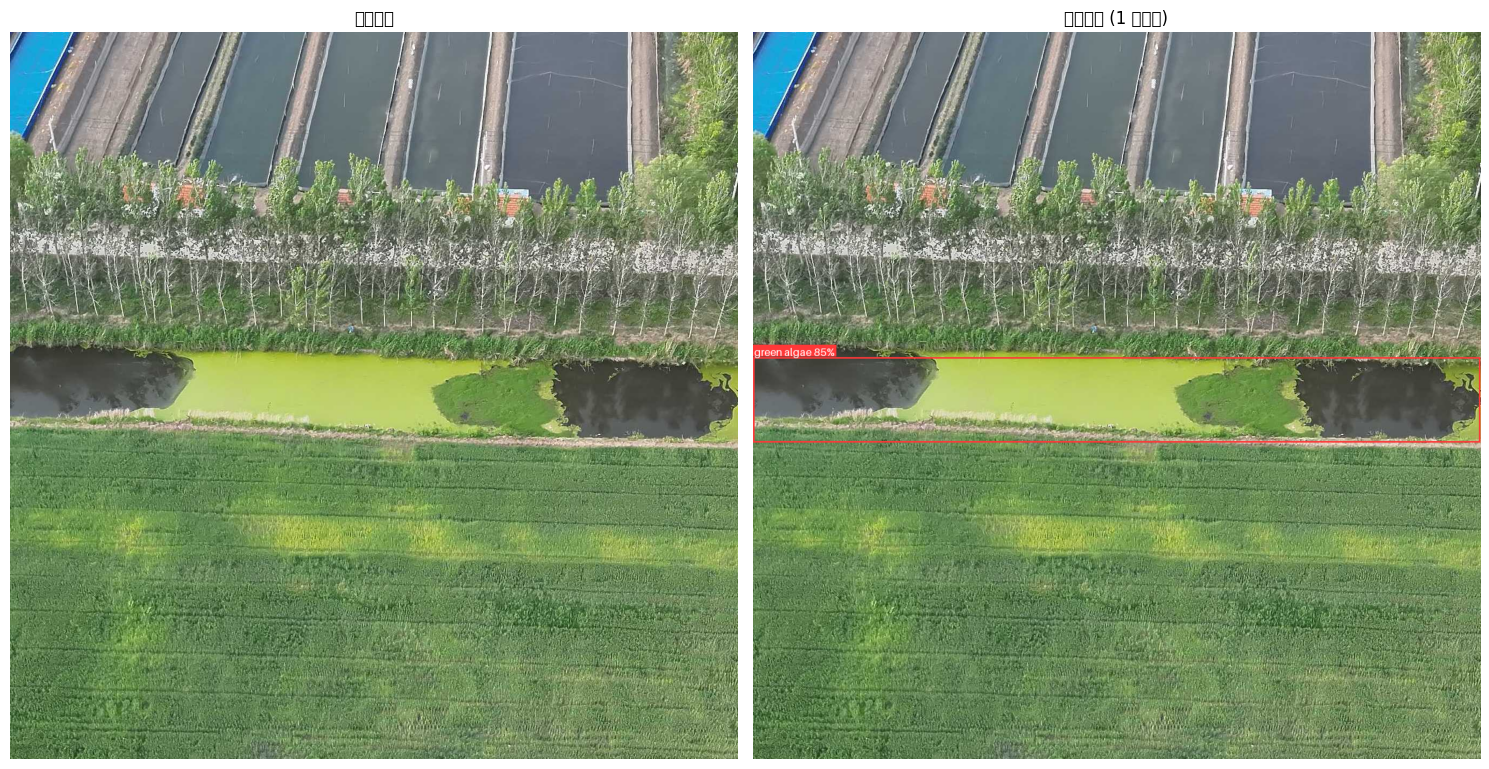


检测结果详情:
  1. green algae - 置信度 85%
     边界框: [0, 606, 1351, 764]

测试成功!


{'image_source': 'https://fsimage.guihuao.com/images/28b37a22-2e2e-4adc-8e94-eedc986d26a9/5147493742738931713.jpeg?imageMogr2/crop/!1353x1353a1311a823',
 'query': '检测图中的水面绿藻, 使用green algae作为标签',
 'success': True,
 'image_size': (1353, 1353),
 'raw_response': 'user\n\n\n\n\n请仔细分析这张图片，检测图中的水面绿藻, 使用green algae作为标签。\n\n如果检测到目标，请严格按照以下JSON格式返回检测结果（不要添加其他文字说明）:\n[\n  {"box_2d": [y1, x1, y2, x2], "label": "目标类别", "confidence": 置信度}\n]\n\n坐标说明:\n- box_2d: 边界框坐标 [y1, x1, y2, x2]，基于1000x1000坐标系\n- y1, y2: 垂直方向坐标 (0-1000)，y1 < y2\n- x1, x2: 水平方向坐标 (0-1000)，x1 < x2\n- confidence: 置信度分数 (0.0-1.0)\n\n如果未检测到目标，请返回空数组: []\nmodel\n[\n  {"box_2d": [448, 0, 565, 999], "label": "green algae"}\n]',
 'detections': [{'bbox': [0, 606, 1351, 764],
   'label': 'green algae',
   'confidence': 0.85}],
 'num_detections': 1,
 'result_image': <PIL.Image.Image image mode=RGB size=1353x1353>}

In [18]:
# 运行测试示例
run_test()

In [19]:
# 运行交互式检测
# interactive_detection()

---

# 附录: 错误处理参考

## 常见错误及解决方案

| 错误类型 | 可能原因 | 解决方案 |
|----------|----------|----------|
| `FileNotFoundError` | 图像路径错误 | 检查路径是否正确 |
| `requests.RequestException` | 网络请求失败 | 检查网络连接或使用本地图片 |
| `ValueError: 不支持的格式` | 图像格式不支持 | 使用 jpg/png 等常见格式 |
| `模型未加载` | 模型初始化失败 | 检查模型路径和配置 |
| `未检测到目标` | 模型未找到指定对象 | 尝试不同的查询或检查图像 |

## 注意事项
1. 确保模型路径正确，LoRA adapter 路径可选
2. 图像 URL 需要可公开访问
3. 检测查询建议使用标准格式 '检测图中的xxx'
4. 首次运行需要先调用 `pipeline.initialize()` 加载模型